In [1]:
%pip install -q duckdb matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
FILE_PATH = r"D:\256_group_dataset\HotelRec.txt"
DB_PATH = r"D:\256_group_dataset\hotelrec_explore.duckdb"
USER_COL = "author"
ITEM_COL = "hotel_url"
HEADER = True

In [3]:
import json
import pandas as pd

# quick sanity check to ensure database is loaded properly
with open(FILE_PATH, "r", encoding="utf-8") as f:
    first_line = f.readline()

review = json.loads(first_line)
display(pd.DataFrame([review]))

,hotel_url,author,date,rating,title,text,property_dict
0,Hotel_Review-g194775-d1121769-Reviews-Hotel_Ba...,violettaf340,2019-01-01T00:00:00,5.0,Xmas holiday,We went here with our kids for Xmas holiday an...,{}


In [4]:
import os
import duckdb

# create duckDB to store database without having to store everything at once in memory
tmp_dir = os.path.join(os.path.dirname(DB_PATH), "duckdb_tmp")
os.makedirs(tmp_dir, exist_ok=True)

con = duckdb.connect(DB_PATH)
con.execute("PRAGMA threads=4;")
con.execute(f"SET temp_directory='{tmp_dir}';")

safe_path = FILE_PATH.replace("'", "''")

con.execute("DROP TABLE IF EXISTS hotelrec_reviews")

con.execute(f"""
CREATE TABLE hotelrec_reviews AS
SELECT *
FROM read_json(
    '{safe_path}',
    columns = {{
        author: 'VARCHAR',
        hotel_url: 'VARCHAR',
        date: 'TIMESTAMP',
        rating: 'DOUBLE',
        title: 'VARCHAR',
        text: 'VARCHAR',
        property_dict: 'STRUCT("sleep quality" DOUBLE, value DOUBLE, rooms DOUBLE, service DOUBLE, cleanliness DOUBLE, location DOUBLE)'
    }},
    format = 'auto',
    ignore_errors = true
)
""")

print("hotelrec_reviews created successfully.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

hotelrec_reviews created successfully.


In [45]:
# Total Counts of users, items, and interactions
# Cell 4 — Total counts of users, items, and interactions
result = con.execute("""
    SELECT
        COUNT(*) AS n_interactions,
        COUNT(DISTINCT author) AS n_users,
        COUNT(DISTINCT hotel_url) AS n_items
    FROM hotelrec_reviews
""").fetchdf()

display(result)
user_counts = con.execute("""
    SELECT author, COUNT(*) AS n_reviews
    FROM hotelrec_reviews
    GROUP BY author
""").fetchdf()

item_counts = con.execute("""
    SELECT hotel_url, COUNT(*) AS n_reviews
    FROM hotelrec_reviews
    GROUP BY hotel_url
""").fetchdf()

def summarize_counts(df, col_name):
    s = df[col_name]
    values = [len(s), s.mean(), s.median(), s.min(), s.max(),
              s.quantile(0.25), s.quantile(0.75), s.quantile(0.90),
              s.quantile(0.95), s.quantile(0.99)]
    return pd.DataFrame({
        "metric": ["count","mean","median","min","max","p25","p75","p90","p95","p99"],
        "value": [f"{round(v):,}" for v in values]
    })

print("User interaction summary")
display(summarize_counts(user_counts, "n_reviews"))

print("Hotel interaction summary")
display(summarize_counts(item_counts, "n_reviews"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_interactions,n_users,n_items
0,50264531,21891404,365057


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

User interaction summary


,metric,value
0,count,"21,891,404"
1,mean,2
2,median,1
3,min,1
4,max,"1,193,017"
5,p25,1
6,p75,2
7,p90,4
8,p95,7
9,p99,18


Hotel interaction summary


,metric,value
0,count,"365,057"
1,mean,138
2,median,41
3,min,1
4,max,"10,338"
5,p25,16
6,p75,128
7,p90,331
8,p95,535
9,p99,"1,362"


In [46]:
n_interactions = int(result["n_interactions"].iloc[0])
n_users = int(result["n_users"].iloc[0])
n_items = int(result["n_items"].iloc[0])

possible = n_users * n_items
sparsity = 1 - (n_interactions / possible)
density = n_interactions / possible

print(f"Possible interactions: {possible:,.0f}")
print(f"Actual interactions:   {n_interactions:,.0f}")
print(f"Sparsity:              {sparsity:.8f}  ({sparsity*100:.6f}%)")
print(f"Density:               {density:.2e}")
print()

# What sparsity looks like after common k-core filters
for k in [2, 3, 5, 10]:
    eligible_users = (user_counts["n_reviews"] >= k).sum()
    eligible_items = (item_counts["n_reviews"] >= k).sum()
    new_possible = eligible_users * eligible_items
    print(f"k-core >= {k:>2}: {eligible_users:>10,} users × {eligible_items:>8,} items = "
          f"{new_possible:,.0f} possible  (users drop {100*(1 - eligible_users/n_users):.1f}%)")

Possible interactions: 7,991,610,270,028
Actual interactions:   50,264,531
Sparsity:              0.99999371  (99.999371%)
Density:               6.29e-06

k-core >=  2:  7,103,979 users ×  365,013 items = 2,593,044,686,727 possible  (users drop 67.5%)
k-core >=  3:  4,081,761 users ×  365,007 items = 1,489,871,337,327 possible  (users drop 81.4%)
k-core >=  5:  2,030,354 users ×  364,991 items = 741,060,936,814 possible  (users drop 90.7%)
k-core >= 10:    699,517 users ×  326,131 items = 228,134,178,727 possible  (users drop 96.8%)


In [11]:
user_cold = pd.DataFrame({
    "bucket": ["exactly 1", "<= 2", "<= 3", "< 5", "< 10"],
    "count": [
        (user_counts["n_reviews"] == 1).sum(),
        (user_counts["n_reviews"] <= 2).sum(),
        (user_counts["n_reviews"] <= 3).sum(),
        (user_counts["n_reviews"] < 5).sum(),
        (user_counts["n_reviews"] < 10).sum(),
    ]
})
user_cold["count"] = user_cold["count"].apply(lambda x: f"{x:,}")
user_cold["percent"] = (user_cold["count"].str.replace(",","").astype(int) / len(user_counts) * 100).round(2).astype(str) + "%"

hotel_cold = pd.DataFrame({
    "bucket": ["exactly 1", "<= 2", "<= 3", "< 5", "< 10", "< 50"],
    "count": [
        (item_counts["n_reviews"] == 1).sum(),
        (item_counts["n_reviews"] <= 2).sum(),
        (item_counts["n_reviews"] <= 3).sum(),
        (item_counts["n_reviews"] < 5).sum(),
        (item_counts["n_reviews"] < 10).sum(),
        (item_counts["n_reviews"] < 50).sum(),
    ]
})
hotel_cold["percent"] = (hotel_cold["count"] / len(item_counts) * 100).round(2).astype(str) + "%"
hotel_cold["count"] = hotel_cold["count"].apply(lambda x: f"{x:,}")

print("User activity buckets")
display(user_cold)

print("Hotel activity buckets")
display(hotel_cold)

User activity buckets


,bucket,count,percent
0,exactly 1,"14,787,425",67.55%
1,<= 2,"17,809,643",81.35%
2,<= 3,"19,125,014",87.36%
3,< 5,"19,861,050",90.73%
4,< 10,"21,191,887",96.8%


Hotel activity buckets


,bucket,count,percent
0,exactly 1,44,0.01%
1,<= 2,50,0.01%
2,<= 3,55,0.02%
3,< 5,66,0.02%
4,< 10,"38,926",10.66%
5,< 50,"199,736",54.71%


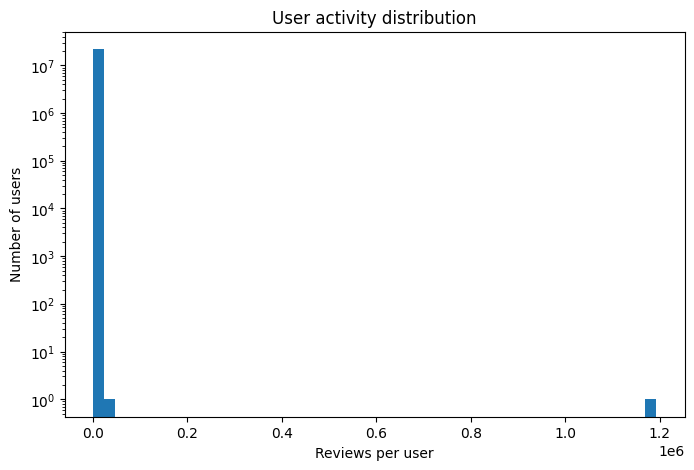

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(user_counts["n_reviews"], bins=50)
plt.xlabel("Reviews per user")
plt.ylabel("Number of users")
plt.title("User activity distribution")
plt.yscale("log")
plt.show()

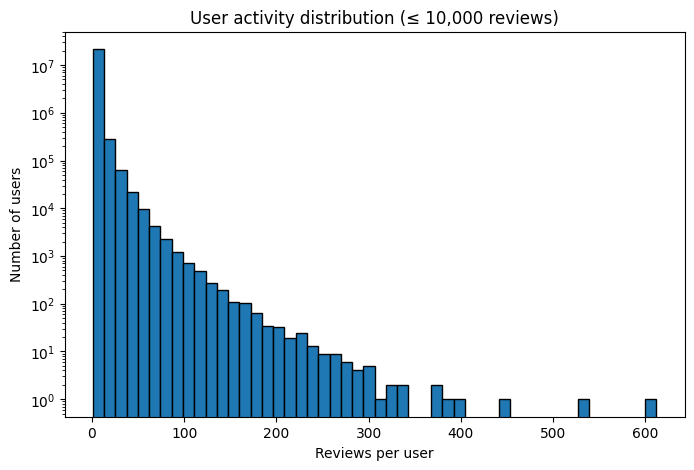

In [16]:
filtered = user_counts[user_counts["n_reviews"] <= 10000]

plt.figure(figsize=(8,5))
plt.hist(filtered["n_reviews"], bins=50, edgecolor="black")
plt.xlabel("Reviews per user")
plt.ylabel("Number of users")
plt.title("User activity distribution (≤ 10,000 reviews)")
plt.yscale("log")
plt.show()

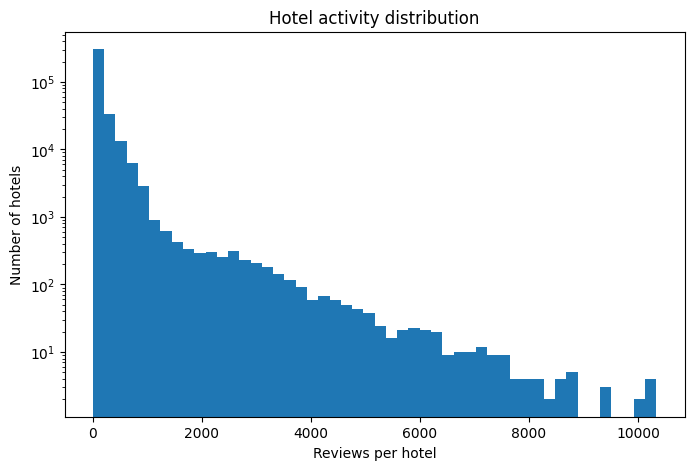

In [13]:
plt.figure(figsize=(8,5))
plt.hist(item_counts["n_reviews"], bins=50)
plt.xlabel("Reviews per hotel")
plt.ylabel("Number of hotels")
plt.title("Hotel activity distribution")
plt.yscale("log")
plt.show()

,rating,cnt,pct
0,1.0,2529778,5.03
1,2.0,2543289,5.06
2,3.0,5644102,11.23
3,4.0,13437531,26.73
4,5.0,26109831,51.94


,global_mean,global_std,null_ratings
0,4.154976,1.123866,0


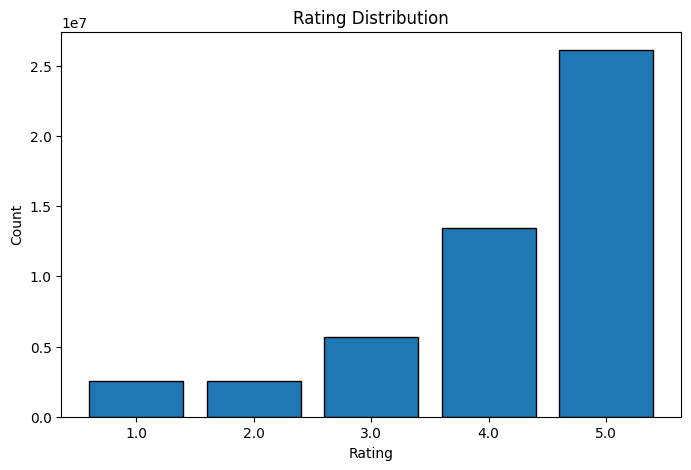

In [20]:
# --- Rating distribution ---
rating_dist = con.execute("""
    SELECT rating, COUNT(*) AS cnt
    FROM hotelrec_reviews
    WHERE rating IS NOT NULL
    GROUP BY rating
    ORDER BY rating
""").fetchdf()

rating_dist["pct"] = (rating_dist["cnt"] / rating_dist["cnt"].sum() * 100).round(2)
display(rating_dist)

# Global mean and std
stats = con.execute("""
    SELECT AVG(rating) AS global_mean,
           STDDEV(rating) AS global_std,
           COUNT(*) FILTER (WHERE rating IS NULL) AS null_ratings
    FROM hotelrec_reviews
""").fetchdf()
display(stats)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(rating_dist["rating"].astype(str), rating_dist["cnt"], edgecolor="black")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()

In [21]:
# --- Per-user and per-item bias ---
# How much does global_mean + user_bias + item_bias explain?
global_mean = stats["global_mean"].iloc[0]

user_bias = con.execute(f"""
    SELECT author, AVG(rating) - {global_mean} AS bias, COUNT(*) AS n
    FROM hotelrec_reviews
    GROUP BY author
""").fetchdf()

item_bias = con.execute(f"""
    SELECT hotel_url, AVG(rating) - {global_mean} AS bias, COUNT(*) AS n
    FROM hotelrec_reviews
    GROUP BY hotel_url
""").fetchdf()

print("User bias stats (deviation from global mean):")
print(user_bias["bias"].describe().round(3))
print()
print("Item bias stats:")
print(item_bias["bias"].describe().round(3))
print()

# Fraction of zero-variance users/items (rate everything the same)
user_var = con.execute("""
    SELECT author, VARIANCE(rating) AS var
    FROM hotelrec_reviews
    GROUP BY author
    HAVING COUNT(*) >= 2
""").fetchdf()

zero_var_users = (user_var["var"] == 0).sum()
print(f"Users with 2+ reviews and zero rating variance: {zero_var_users:,} / {len(user_var):,} "
      f"({100*zero_var_users/len(user_var):.1f}%)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

User bias stats (deviation from global mean):
count    2.189140e+07
mean     5.400000e-02
std      1.104000e+00
min     -3.155000e+00
25%     -1.550000e-01
50%      6.780000e-01
75%      8.450000e-01
max      8.450000e-01
Name: bias, dtype: float64

Item bias stats:
count    365057.000
mean         -0.103
std           0.693
min          -3.155
25%          -0.496
50%           0.012
75%           0.439
max           0.845
Name: bias, dtype: float64



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Users with 2+ reviews and zero rating variance: 2,101,463 / 7,103,979 (29.6%)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Users with 2+ reviews: 7,103,979
count    7103979.000
mean           0.755
std            0.693
min            0.000
25%            0.000
50%            0.707
75%            1.155
max            2.828


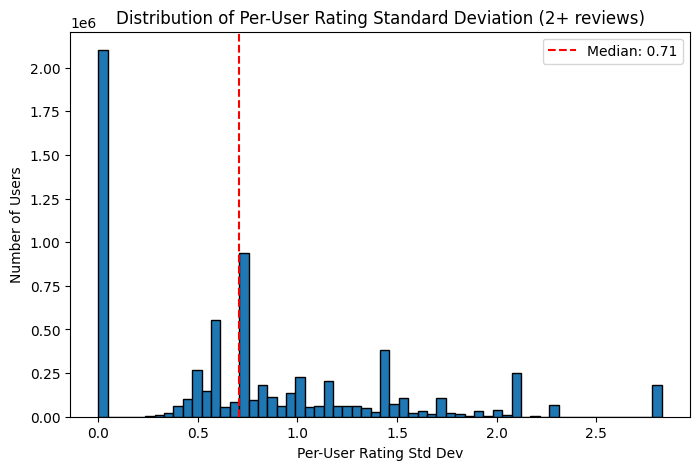

In [47]:
# --- Per-user rating standard deviation ---
user_std = con.execute("""
    SELECT author, STDDEV(rating) AS rating_std, COUNT(*) AS n
    FROM hotelrec_reviews
    GROUP BY author
    HAVING COUNT(*) >= 2
""").fetchdf()

print(f"Users with 2+ reviews: {len(user_std):,}")
print(user_std["rating_std"].describe().round(3).to_string())

plt.figure(figsize=(8, 5))
plt.hist(user_std["rating_std"].dropna(), bins=60, edgecolor="black")
plt.xlabel("Per-User Rating Std Dev")
plt.ylabel("Number of Users")
plt.title("Distribution of Per-User Rating Standard Deviation (2+ reviews)")
plt.axvline(user_std["rating_std"].median(), color="red", linestyle="--", label=f"Median: {user_std['rating_std'].median():.2f}")
plt.legend()
plt.show()

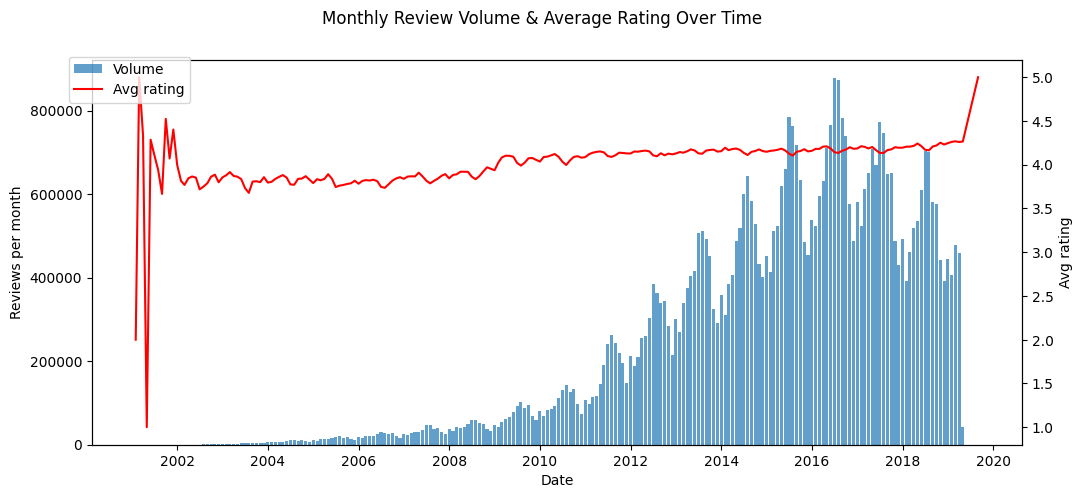

Earliest: 2001-02-01 00:00:00
Latest:   2019-09-01 00:00:00
Span:     18.6 years


In [50]:
# --- Monthly review volume & average rating over time ---
monthly = con.execute("""
    SELECT DATE_TRUNC('month', CAST(date AS TIMESTAMP)) AS month,
           COUNT(*) AS n_reviews,
           AVG(rating) AS avg_rating
    FROM hotelrec_reviews
    WHERE date IS NOT NULL
    GROUP BY month
    ORDER BY month
""").fetchdf()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(monthly["month"], monthly["n_reviews"], width=25, alpha=0.7, label="Volume")
ax1.set_ylabel("Reviews per month")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.plot(monthly["month"], monthly["avg_rating"], color="red", linewidth=1.5, label="Avg rating")
ax2.set_ylabel("Avg rating")

fig.suptitle("Monthly Review Volume & Average Rating Over Time")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()

print(f"Earliest: {monthly['month'].min()}")
print(f"Latest:   {monthly['month'].max()}")
print(f"Span:     {(monthly['month'].max() - monthly['month'].min()).days / 365:.1f} years")

In [23]:
# --- Temporal: rating drift ---
# Yearly avg rating to see if there's a trend (grade inflation/deflation)
yearly = con.execute("""
    SELECT EXTRACT(YEAR FROM CAST(date AS TIMESTAMP)) AS year,
           COUNT(*) AS n,
           AVG(rating) AS avg_rating,
           STDDEV(rating) AS std_rating
    FROM hotelrec_reviews
    WHERE date IS NOT NULL
    GROUP BY year
    ORDER BY year
""").fetchdf()

display(yearly)

,year,n,avg_rating,std_rating
0,2001,227,4.189427,1.206279
1,2002,5769,3.824060,1.449235
2,2003,40491,3.807587,1.369064
3,2004,101611,3.827607,1.347574
4,2005,176003,3.801197,1.340188
5,2006,271538,3.800728,1.331762
6,2007,400361,3.847647,1.314955
7,2008,531618,3.894932,1.310135
8,2009,854978,4.048667,1.192718
9,2010,1230397,4.069266,1.183646


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Users with 2+ reviews: 7,103,979

Lifespan (days) stats:
count    7103979.0
mean         993.6
std          963.1
min            0.0
25%          215.0
50%          730.0
75%         1492.0
max         6676.0
Name: lifespan_days, dtype: float64


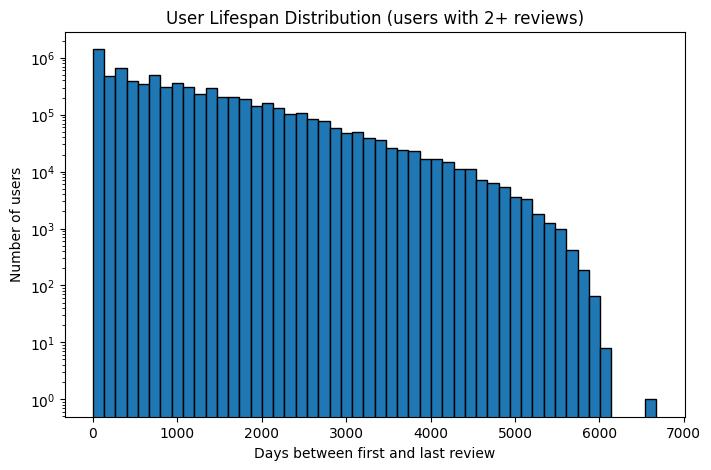

In [24]:
# --- Temporal: user lifespan & repeat behavior ---
# How long between a user's first and last review?
user_temporal = con.execute("""
    SELECT author,
           MIN(CAST(date AS TIMESTAMP)) AS first_review,
           MAX(CAST(date AS TIMESTAMP)) AS last_review,
           COUNT(*) AS n_reviews,
           DATEDIFF('day', MIN(CAST(date AS TIMESTAMP)), MAX(CAST(date AS TIMESTAMP))) AS lifespan_days
    FROM hotelrec_reviews
    WHERE date IS NOT NULL
    GROUP BY author
    HAVING COUNT(*) >= 2
""").fetchdf()

print(f"Users with 2+ reviews: {len(user_temporal):,}")
print(f"\nLifespan (days) stats:")
print(user_temporal["lifespan_days"].describe().round(1))

plt.figure(figsize=(8, 5))
plt.hist(user_temporal["lifespan_days"], bins=50, edgecolor="black")
plt.xlabel("Days between first and last review")
plt.ylabel("Number of users")
plt.title("User Lifespan Distribution (users with 2+ reviews)")
plt.yscale("log")
plt.show()

80% of reviews before: 2017-09
85% of reviews before: 2018-02
90% of reviews before: 2018-07


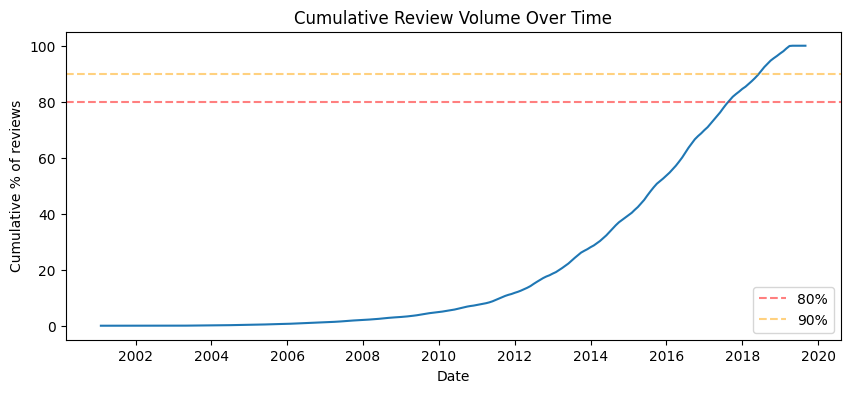

In [25]:
# --- Temporal: natural train/test split candidates ---
# Cumulative % of interactions over time
monthly["cum_pct"] = (monthly["n_reviews"].cumsum() / monthly["n_reviews"].sum() * 100).round(2)

# Find 80/90 percentile dates for chronological splits
for pct in [80, 85, 90]:
    cutoff = monthly[monthly["cum_pct"] >= pct].iloc[0]
    print(f"{pct}% of reviews before: {cutoff['month'].strftime('%Y-%m')}")

plt.figure(figsize=(10, 4))
plt.plot(monthly["month"], monthly["cum_pct"])
plt.axhline(y=80, color="r", linestyle="--", alpha=0.5, label="80%")
plt.axhline(y=90, color="orange", linestyle="--", alpha=0.5, label="90%")
plt.xlabel("Date")
plt.ylabel("Cumulative % of reviews")
plt.title("Cumulative Review Volume Over Time")
plt.legend()
plt.show()

In [26]:
# --- Side-Feature Inventory & Coverage ---
# Check what columns exist and null rates
col_stats = con.execute("""
    SELECT
        COUNT(*) AS total,
        COUNT(rating) AS has_rating,
        COUNT(CASE WHEN rating IS NULL THEN 1 END) AS null_rating,
        COUNT(title) AS has_title,
        COUNT(CASE WHEN title IS NULL OR TRIM(title) = '' THEN NULL ELSE 1 END) AS nonempty_title,
        COUNT(text) AS has_text,
        COUNT(CASE WHEN text IS NULL OR TRIM(text) = '' THEN NULL ELSE 1 END) AS nonempty_text,
        COUNT(date) AS has_date,
        COUNT(property_dict) AS has_property_dict,
        COUNT(CASE WHEN property_dict IS NULL OR property_dict = '{}' THEN NULL ELSE 1 END) AS nonempty_property_dict
    FROM hotelrec_reviews
""").fetchdf()

total = col_stats["total"].iloc[0]
for col in col_stats.columns:
    if col == "total": continue
    print(f"{col:>30}: {col_stats[col].iloc[0]:>12,}  ({100*col_stats[col].iloc[0]/total:.2f}%)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                    has_rating:   50,264,531  (100.00%)
                   null_rating:            0  (0.00%)
                     has_title:   50,264,531  (100.00%)
                nonempty_title:   50,263,922  (100.00%)
                      has_text:   50,264,531  (100.00%)
                 nonempty_text:   50,264,528  (100.00%)
                      has_date:   50,264,531  (100.00%)
             has_property_dict:   50,264,531  (100.00%)
        nonempty_property_dict:   35,836,245  (71.30%)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Review text length (chars):
count    50264528.0
mean          691.0
std           699.0
min             2.0
25%           290.0
50%           476.0
75%           821.0
max         63343.0
Name: text_len, dtype: float64


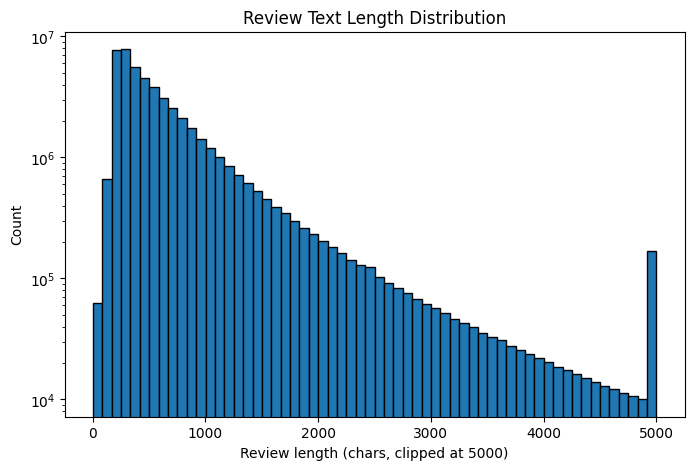

In [30]:
# --- Review text length distribution ---
text_lengths = con.execute("""
    SELECT LENGTH(text) AS text_len
    FROM hotelrec_reviews
    WHERE text IS NOT NULL AND TRIM(text) != ''
""").fetchdf()

print("Review text length (chars):")
print(text_lengths["text_len"].describe().round(0))

plt.figure(figsize=(8, 5))
plt.hist(text_lengths["text_len"].clip(upper=5000), bins=60, edgecolor="black")
plt.xlabel("Review length (chars, clipped at 5000)")
plt.ylabel("Count")
plt.title("Review Text Length Distribution")
plt.yscale("log")
plt.show()

In [28]:
# --- property_dict: what metadata fields exist and how often ---
# Sample non-empty property_dicts to catalog available keys
import json

sample = con.execute("""
    SELECT property_dict
    FROM hotelrec_reviews
    WHERE property_dict IS NOT NULL AND property_dict != '{}'
    USING SAMPLE 10000
""").fetchdf()

key_counts = {}
for row in sample["property_dict"]:
    try:
        d = json.loads(row) if isinstance(row, str) else row
        for k in d:
            key_counts[k] = key_counts.get(k, 0) + 1
    except:
        continue

print(f"Sampled {len(sample)} non-empty property_dicts\n")
print("Key frequency (out of sample):")
for k, v in sorted(key_counts.items(), key=lambda x: -x[1]):
    print(f"  {k:>30}: {v:>6} ({100*v/len(sample):.1f}%)")

Sampled 7170 non-empty property_dicts

Key frequency (out of sample):
                   sleep quality:   7170 (100.0%)
                           value:   7170 (100.0%)
                           rooms:   7170 (100.0%)
                         service:   7170 (100.0%)
                     cleanliness:   7170 (100.0%)
                        location:   7170 (100.0%)


In [37]:
# --- Sub-rating distributions & coverage ---
sub_ratings = con.execute("""
    SELECT
        rating AS overall,
        property_dict."sleep quality" AS sleep_quality,
        property_dict.value AS value,
        property_dict.rooms AS rooms,
        property_dict.service AS service,
        property_dict.cleanliness AS cleanliness,
        property_dict.location AS location
    FROM hotelrec_reviews
    WHERE property_dict IS NOT NULL
""").fetchdf()

print(f"Rows with property_dict: {len(sub_ratings):,}")
print(f"\nNull rates per sub-rating:")
print((sub_ratings.isna().sum() / len(sub_ratings) * 100).round(2).to_string())
print(f"\nRows with ALL sub-ratings present: {sub_ratings.dropna().shape[0]:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows with property_dict: 50,264,531

Null rates per sub-rating:
overall           0.00
sleep_quality    55.05
value            47.50
rooms            49.43
service          29.23
cleanliness      47.47
location         49.23

Rows with ALL sub-ratings present: 15,698,199


In [38]:
# --- Sub-rating descriptive stats ---
sub_cols = ["sleep_quality", "value", "rooms", "service", "cleanliness", "location"]
print(sub_ratings[sub_cols + ["overall"]].describe().round(2).to_string())

       sleep_quality        value        rooms      service  cleanliness     location      overall
count    22592252.00  26386737.00  25416751.00  35573443.00  26406100.00  25521473.00  50264531.00
mean            4.21         4.12         4.12         4.29         4.33         4.40         4.15
std             1.08         1.13         1.10         1.09         1.03         0.88         1.12
min             1.00         0.00         0.00         0.00         0.00         0.00         1.00
25%             4.00         4.00         4.00         4.00         4.00         4.00         4.00
50%             5.00         5.00         4.00         5.00         5.00         5.00         5.00
75%             5.00         5.00         5.00         5.00         5.00         5.00         5.00
max             5.00         5.00         5.00         5.00         5.00         5.00         5.00


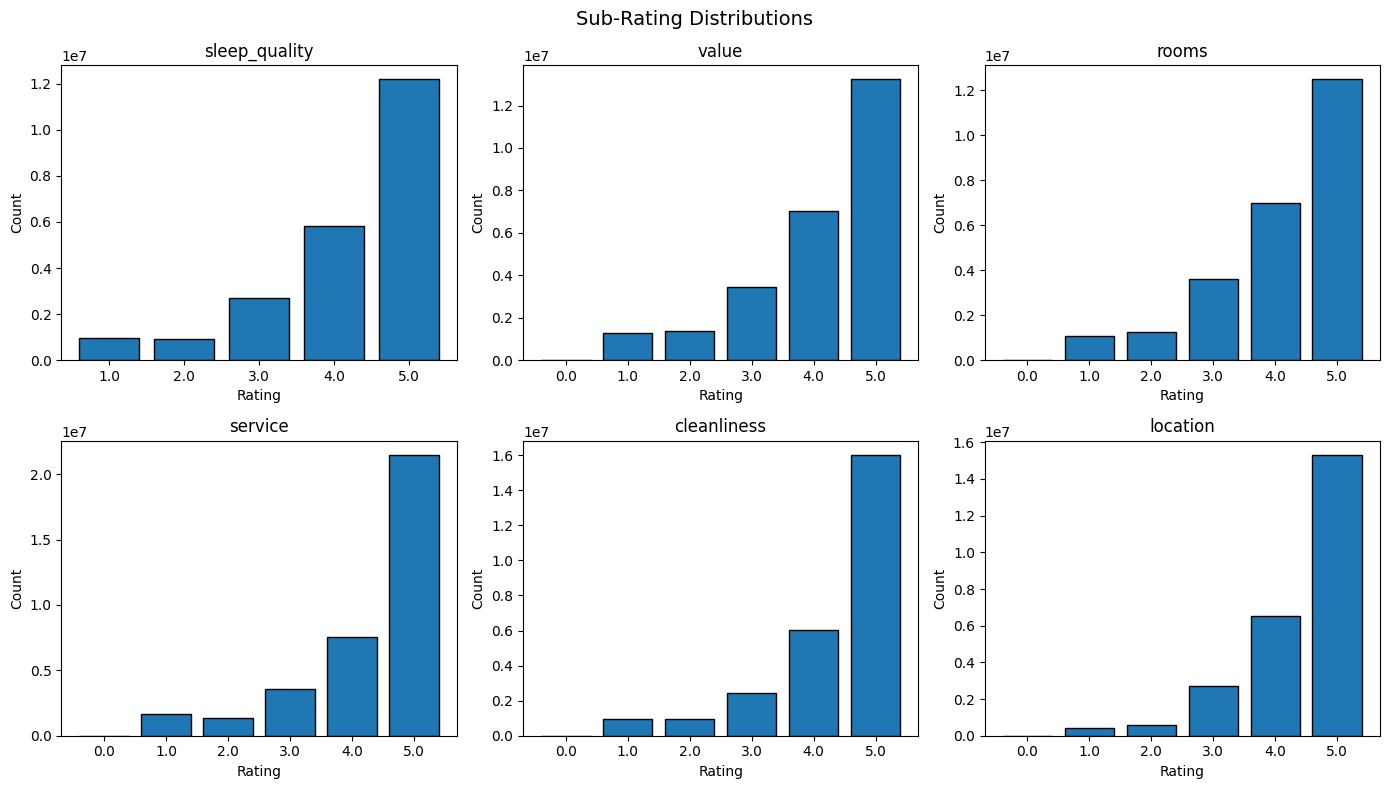

In [39]:
# --- Distribution of each sub-rating ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), sub_cols):
    counts = sub_ratings[col].dropna().value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel("Rating")
    ax.set_ylabel("Count")
fig.suptitle("Sub-Rating Distributions", fontsize=14)
fig.tight_layout()
plt.show()

Correlation matrix:
               overall  sleep_quality  value  rooms  service  cleanliness  location
overall          1.000          0.768  0.807  0.827    0.806        0.790     0.582
sleep_quality    0.768          1.000  0.701  0.770    0.663        0.716     0.522
value            0.807          0.701  1.000  0.744    0.733        0.710     0.547
rooms            0.827          0.770  0.744  1.000    0.700        0.796     0.549
service          0.806          0.663  0.733  0.700    1.000        0.708     0.526
cleanliness      0.790          0.716  0.710  0.796    0.708        1.000     0.529
location         0.582          0.522  0.547  0.549    0.526        0.529     1.000


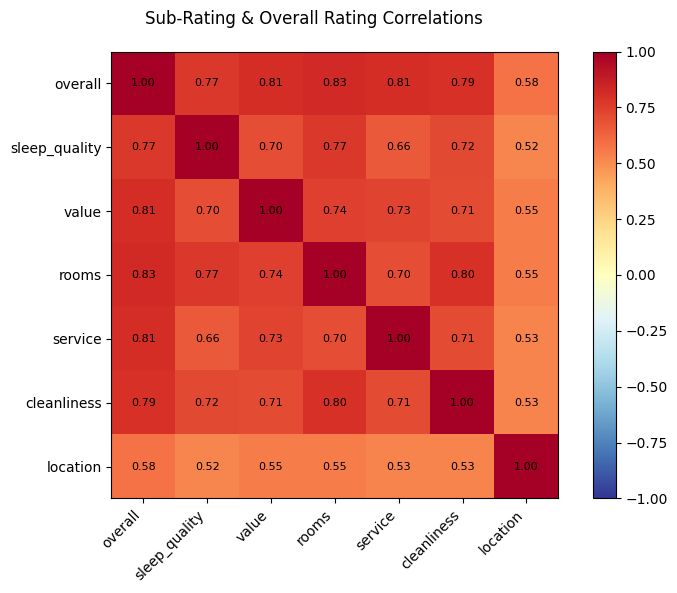

In [40]:
# --- Correlation matrix: sub-ratings vs overall ---
corr = sub_ratings.dropna().corr()
print("Correlation matrix:")
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="RdYlBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im)
fig.suptitle("Sub-Rating & Overall Rating Correlations")
fig.tight_layout()
plt.show()

In [31]:
geo_codes = con.execute(r"""
    SELECT REGEXP_EXTRACT(hotel_url, 'g(\d+)', 1) AS geo_id,
           COUNT(DISTINCT hotel_url) AS n_hotels,
           COUNT(*) AS n_reviews
    FROM hotelrec_reviews
    GROUP BY geo_id
    ORDER BY n_reviews DESC
    LIMIT 20
""").fetchdf()

distinct_geo = con.execute(r"""
    SELECT COUNT(DISTINCT REGEXP_EXTRACT(hotel_url, 'g(\d+)', 1)) FROM hotelrec_reviews
""").fetchone()[0]

print(f"Distinct geo codes: {distinct_geo:,}")
print("\nTop 20 geo codes by review volume:")
display(geo_codes)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Distinct geo codes: 40,771

Top 20 geo codes by review volume:


,geo_id,n_hotels,n_reviews
0,186338,1618,728654
1,60763,400,424050
2,187147,1673,355825
3,293916,1663,351439
4,187791,3189,338524
5,34515,231,297532
6,295424,544,265362
7,187497,988,211518
8,188590,664,197186
9,293974,1736,183666


In [36]:
# --- Duplicate (author, hotel_url) pairs ---
dupes = con.execute("""
    SELECT COUNT(*) AS total_dupes, COUNT(DISTINCT author) AS users_with_dupes
    FROM (
        SELECT author, hotel_url, COUNT(*) AS n
        FROM hotelrec_reviews
        GROUP BY author, hotel_url
        HAVING COUNT(*) > 1
    )
""").fetchdf()
display(dupes)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_dupes,users_with_dupes
0,1068974,832605


In [33]:
# --- Null / invalid value audit ---
quality = con.execute("""
    SELECT
        COUNT(*) AS total,
        COUNT(CASE WHEN author IS NULL OR TRIM(author) = '' THEN 1 END) AS null_author,
        COUNT(CASE WHEN hotel_url IS NULL OR TRIM(hotel_url) = '' THEN 1 END) AS null_hotel,
        COUNT(CASE WHEN rating IS NULL THEN 1 END) AS null_rating,
        COUNT(CASE WHEN rating NOT BETWEEN 1 AND 5 THEN 1 END) AS rating_out_of_range,
        COUNT(CASE WHEN date IS NULL THEN 1 END) AS null_date,
        MIN(rating) AS min_rating,
        MAX(rating) AS max_rating
    FROM hotelrec_reviews
""").fetchdf()

for col in quality.columns:
    print(f"{col:>25}: {quality[col].iloc[0]}")

                    total: 50264531
              null_author: 0
               null_hotel: 0
              null_rating: 0
      rating_out_of_range: 0
                null_date: 0
               min_rating: 1.0
               max_rating: 5.0


In [34]:
# --- Bot / suspicious user detection ---
# Users with extremely high review counts
top_users = con.execute("""
    SELECT author, COUNT(*) AS n_reviews,
           MIN(CAST(date AS TIMESTAMP)) AS first,
           MAX(CAST(date AS TIMESTAMP)) AS last,
           DATEDIFF('day', MIN(CAST(date AS TIMESTAMP)), MAX(CAST(date AS TIMESTAMP))) AS span_days,
           COUNT(*) * 1.0 / NULLIF(DATEDIFF('day', MIN(CAST(date AS TIMESTAMP)), MAX(CAST(date AS TIMESTAMP))), 0) AS reviews_per_day
    FROM hotelrec_reviews
    GROUP BY author
    ORDER BY n_reviews DESC
    LIMIT 20
""").fetchdf()

print("Top 20 users by volume (bot candidates):")
display(top_users)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Top 20 users by volume (bot candidates):


,author,n_reviews,first,last,span_days,reviews_per_day
0,/undefined,1193017,2001-02-01,2019-05-14 00:06:23,6676,178.702367
1,null,23889,2002-11-01,2019-05-02 21:00:55,6026,3.964321
2,AGoingGal,612,2012-04-01,2019-04-18 00:00:00,2573,0.237855
3,TravelManSouth,536,2011-07-01,2019-04-25 00:00:00,2855,0.187741
4,WeeLuv2Travel2,443,2006-07-01,2019-04-17 00:00:00,4673,0.094800
5,811bernardf,395,2015-03-01,2019-03-01 00:00:00,1461,0.270363
6,Odyssey802719,386,2005-11-01,2019-05-03 00:00:00,4931,0.078280
7,Riesst,378,2006-10-01,2019-01-01 00:00:00,4475,0.084469
8,mrsbrojoe,371,2011-08-01,2019-03-01 00:00:00,2769,0.133983
9,Victorianlad,343,2008-03-01,2018-12-01 00:00:00,3927,0.087344
